# RNA-Binding Prediction with eCLIP Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgruano/elixir_AI4LS_rna_binding/blob/main/rna_binding_eclip.ipynb)

This notebook provides a starter template to fetch, inspect, and analyze the processed **eCLIP dataset** from Hugging Face ([`morrislab/eclip`](https://huggingface.co/datasets/morrislab/eclip), part of [mRNABench](https://github.com/morrislab/mRNABench)).

### Biological Question
Proteins and RNA do not act as independent biomolecules, but orchestrate cellular biology through protein-RNA interactions. Cross-linking experiments (such as eCLIP) followed by RNA sequencing detect transcriptome-wide binding events.

**Could training a machine learning model on this data be able to predict if a given protein binds to a given RNA molecule?**

## 1. Environment Setup & Dependencies

Install the Hugging Face `datasets` library, `pyarrow`, and `matplotlib` to read parquet-formatted biological datasets and create visualizations in Google Colab.

In [5]:
# Install required libraries in Colab
%pip install -q datasets pandas pyarrow matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Fetch Dataset from Hugging Face

The `morrislab/eclip` dataset contains eCLIP binding data across human cell lines:
- **`k562`**: Erythroleukemia cell line (~120+ RBPs)
- **`hepg2`**: Hepatocellular carcinoma cell line

We load the dataset using Hugging Face's `datasets` library.

In [6]:
from datasets import load_dataset
import pandas as pd

# Choose cell line configuration: 'k562' or 'hepg2'
CONFIG = "k562"

print(f"Fetching morrislab/eclip dataset (config: {CONFIG})...")
dataset = load_dataset("morrislab/eclip", CONFIG)
print("Dataset fetched successfully!\n")
print(dataset)

Fetching morrislab/eclip dataset (config: k562)...
Dataset fetched successfully!

DatasetDict({
    train: Dataset({
        features: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice', 'target_AATF', 'target_ABCF1', 'target_AKAP1', 'target_APOBEC3C', 'target_AQR', 'target_BCCIP', 'target_BUD13', 'target_CDC40', 'target_CPEB4', 'target_CPSF6', 'target_CSTF2', 'target_CSTF2T', 'target_DDX21', 'target_DDX24', 'target_DDX3X', 'target_DDX42', 'target_DDX51', 'target_DDX52', 'target_DDX55', 'target_DDX6', 'target_DGCR8', 'target_DHX30', 'target_DKC1', 'target_DROSHA', 'target_EFTUD2', 'target_EIF3D', 'target_EIF3G', 'target_EIF3H', 'target_EIF4G2', 'target_EWSR1', 'target_EXOSC5', 'target_FAM120A', 'target_FASTKD2', 'target_FKBP4', 'target_FMR1', 'target_FXR1', 'target_FXR2', 'target_G3BP1', 'target_GEMIN5', 'target_GNL3', 'target_GPKOW', 'target_GRSF1', 'target_HLTF', 'target_HNRNPA1', 'target_HNRNPC', 'target_HNRNPL', 'target_HNRNPM', 'target_HNRNPU', 'target_HNRNPUL1', 

## 3. Data Exploration

Convert the training split into a pandas DataFrame to inspect the transcript metadata, RNA sequences, and target binding annotations.

In [7]:
# Convert train split to DataFrame
df = dataset["train"].to_pandas()
print(f"Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")

# View metadata columns (transcripts, gene names, chromosomes, sequences)
meta_cols = [c for c in df.columns if not c.startswith("target_")]
print("Sequence metadata columns:", meta_cols)
df[meta_cols].head()

Dataset dimensions: 15717 rows x 128 columns

Sequence metadata columns: ['transcript_id', 'gene', 'chromosome', 'sequence', 'cds', 'splice']


,transcript_id,gene,chromosome,sequence,cds,splice
0,ENST00000433834,CAPZB,1,TCCCTGTACCTGGGGCGCGCCTTCTTTGCAGCCTTTGGGGAGCGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ENST00000411827,CDC42,1,CGCTGACGTCAGGTGCGTGCCCCTGTCCGGCAGCCGAGGAGACCCC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ENST00000517138,SCARNA1,1,CAGCACTTGATACTAACCGAGCTGTCTATATCCTAGCCTTGTGTCA...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ENST00000408612,SNORD99,1,ACTGGTCCAGGATGAAACCTAATTTGAGTGGACATCCATGGATGAG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ENST00000410852,RN7SKP91,1,AAATGTGAGGGTGATCTGGCTGTGACATCTGTCACCCTATTGATCG...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## 4. Explore Available RNA-Binding Proteins (RBPs)

Columns prefixed with `target_` contain binary binding labels for individual RNA-binding proteins profiled by eCLIP.

In [8]:
# List all profiled RBPs
target_cols = [c for c in df.columns if c.startswith("target_")]
rbp_names = [c.replace("target_", "") for c in target_cols]

print(f"Total RBP targets profiled: {len(rbp_names)}")
print("Sample of 20 available RBPs:", rbp_names[:20])

Total RBP targets profiled: 122
Sample of 20 available RBPs: ['AATF', 'ABCF1', 'AKAP1', 'APOBEC3C', 'AQR', 'BCCIP', 'BUD13', 'CDC40', 'CPEB4', 'CPSF6', 'CSTF2', 'CSTF2T', 'DDX21', 'DDX24', 'DDX3X', 'DDX42', 'DDX51', 'DDX52', 'DDX55', 'DDX6']


## 5. Select a Target RBP and Inspect Binding Profile

Select an RBP of interest to analyze its binding frequency and sequence properties across transcripts.

Analyzing target: AATF
Binding label distribution:
target_AATF
0    15545
1      172
Name: count, dtype: int64

Sequence length summary (nt):
count     15717.000000
mean       3304.072915
std        3226.434201
min          57.000000
25%        1394.000000
50%        2620.000000
75%        4395.000000
max      205012.000000
Name: seq_length, dtype: float64


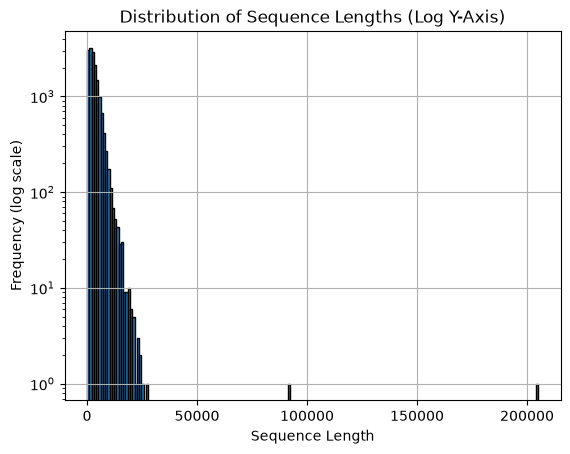

In [9]:
import matplotlib.pyplot as plt

# Pick an RBP of interest (e.g. ELAVL1 if present, otherwise the first target)
selected_rbp = "ELAVL1" if "target_ELAVL1" in df.columns else rbp_names[0]
target_col = f"target_{selected_rbp}"

print(f"Analyzing target: {selected_rbp}")
print("Binding label distribution:")
print(df[target_col].value_counts(dropna=False))

# Inspect RNA sequence lengths
df["seq_length"] = df["sequence"].str.len()
print("\nSequence length summary (nt):")
print(df["seq_length"].describe())

# Initial distribution with log y-axis to observe length span
df["seq_length"].hist(bins=200, edgecolor="black", log=True)
plt.title("Distribution of Sequence Lengths (Log Y-Axis)")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency (log scale)")
plt.show()

## 6. Filter Sequences Longer than 5000 nt & Plot Linear Distribution

Filter out sequences longer than 5,000 nucleotides and display the updated sequence length distribution on a linear (non-log) scale.

Original sequence count: 15717
Filtered sequence count (<= 5000 nt): 12584

Filtered sequence length summary (nt):
count    12584.000000
mean      2228.645820
std       1299.117799
min         57.000000
25%       1111.000000
50%       2112.000000
75%       3229.250000
max       4999.000000
Name: seq_length, dtype: float64


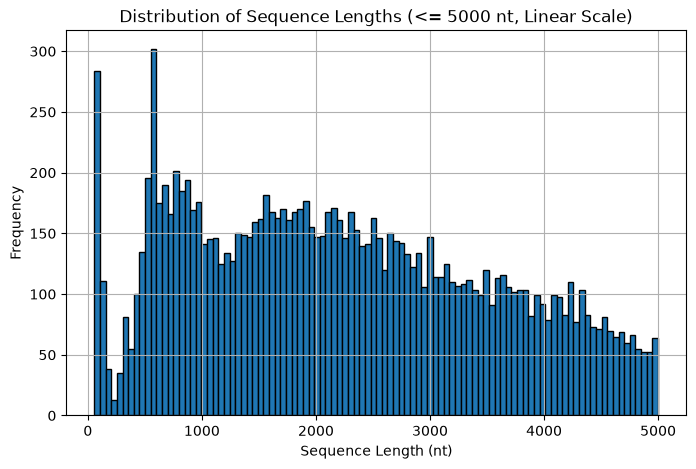

In [10]:
# Filter sequences with length <= 5000 nt
print(f"Original sequence count: {len(df)}")
df = df[df["seq_length"] <= 5000].reset_index(drop=True)
print(f"Filtered sequence count (<= 5000 nt): {len(df)}")

# Summary of filtered sequence lengths
print("\nFiltered sequence length summary (nt):")
print(df["seq_length"].describe())

# Plot distribution on a linear scale (not log)
plt.figure(figsize=(8, 5))
df["seq_length"].hist(bins=100, edgecolor="black")
plt.title("Distribution of Sequence Lengths (<= 5000 nt, Linear Scale)")
plt.xlabel("Sequence Length (nt)")
plt.ylabel("Frequency")
plt.show()

## 7. Next Steps: Sequence Preprocessing & Model Training

Use the space below to implement sequence preprocessing (e.g. one-hot encoding, tokenization) and model training (e.g. 1D-CNN, Transformer, or baseline classifiers).

In [ ]:
# Starter code for sequence inspection / feature extraction
sample_seq = df["sequence"].iloc[0]
print(f"Sample RNA sequence (first 100 nt):\n{sample_seq[:100]}...")